In [33]:
import os
participants_data_filename = "/home/martin/data_imaging/Muscle/data_sarcopenia_tx/Doc Unificado 19022026.xlsx"
pelvis_mri_results_path = "/home/martin/data_imaging/Muscle/data_sarcopenia_tx/nifti_pelvis/"
lumbar_mri_results_path = "/home/martin/data_imaging/Muscle/data_sarcopenia_tx/nifti_pelvis/"
output_dir = "/home/martin/data_imaging/Muscle/data_sarcopenia_tx/statistical_analysis/"

#participants_data_filename = "d:/data_sarcopenia_tx/Doc Unificado 20082025.xlsx"
#pelvis_mri_results_path = "d:/data_sarcopenia_tx/nifti_pelvis/"
#lumbar_mri_results_path = "d:/data_sarcopenia_tx/nifti_pelvis/"
#output_path = "d:/data_sarcopenia_tx/statistical_analysis/"

volume_ff_filename_per_subject = "volumes_and_ffs.csv"
column_names = ["VOL_LGMAX", "VOL_LGMED", "VOL_LGMIN", "VOL_LTFL", "VOL_RGMAX", "VOL_RGMED", "VOL_RGMIN", "VOL_RTFL",
                "FF_LGMAX", "FF_LGMED", "FF_LGMIN", "FF_LTFL", "FF_RGMAX", "FF_RGMED", "FF_RGMIN", "FF_RTFL"]
os.makedirs(output_dir, exist_ok=True)

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns   
import scipy.stats as stats

# Load the data
data = pd.read_excel(participants_data_filename, sheet_name='Doc Unificado')

# print column names
print("Column names in the dataset:")
print(data.columns)


Column names in the dataset:
Index(['ID', 'Grupo', 'Sexo', 'Edad', 'Fecha Reclutamiento', 'Cuestionarios',
       'Resonancia', 'Fecha de nacimiento',
       '¿Cuál es su altura aproximadamente?\nPoner la altura en centímetros',
       '¿Cuál es su peso aproximadamente?\nPoner el peso en kilgramos',
       ...
       'Proteinuria 24hs', 'Creatininuria', 'Sodio.1', 'Potasio.1', 'Cloro.1',
       'TSH', 'PTH intacta', '250H VitD', 'Inmunosupresor', 'PCR'],
      dtype='object', length=101)


=== Descriptive Statistics by Group ===

Age by Group:
            count       mean       std   min    25%   50%    75%   max
Grupo                                                                 
control      13.0  50.461538  6.514284  41.0  46.00  50.0  56.00  60.0
diálisis      8.0  47.750000  6.181770  39.0  42.75  47.5  53.25  56.0
trasplante   22.0  47.681818  5.384160  40.0  42.25  48.5  51.00  59.0


Sex Distribution by Group:
Sexo        Femenino  Masculino
Grupo                          
control           10          3
diálisis           4          4
trasplante         9         13


BMI by Group:
            count  unique        top  freq
Grupo                                     
control      13.0    13.0  30.730609   1.0
diálisis      8.0     8.0  27.428571   1.0
trasplante   22.0    21.0  23.046875   2.0


Mean Left Grip Strength by Group:
            count       mean        std        min        25%        50%  \
Grupo                                                     

/tmp/ipykernel_2285860/4277100704.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Edad', data=data, ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_2285860/4277100704.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='BMI', data=data, ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_2285860/4277100704.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Max_Any_Side', data=data, ax=axes[1, 1], palette='Set2')


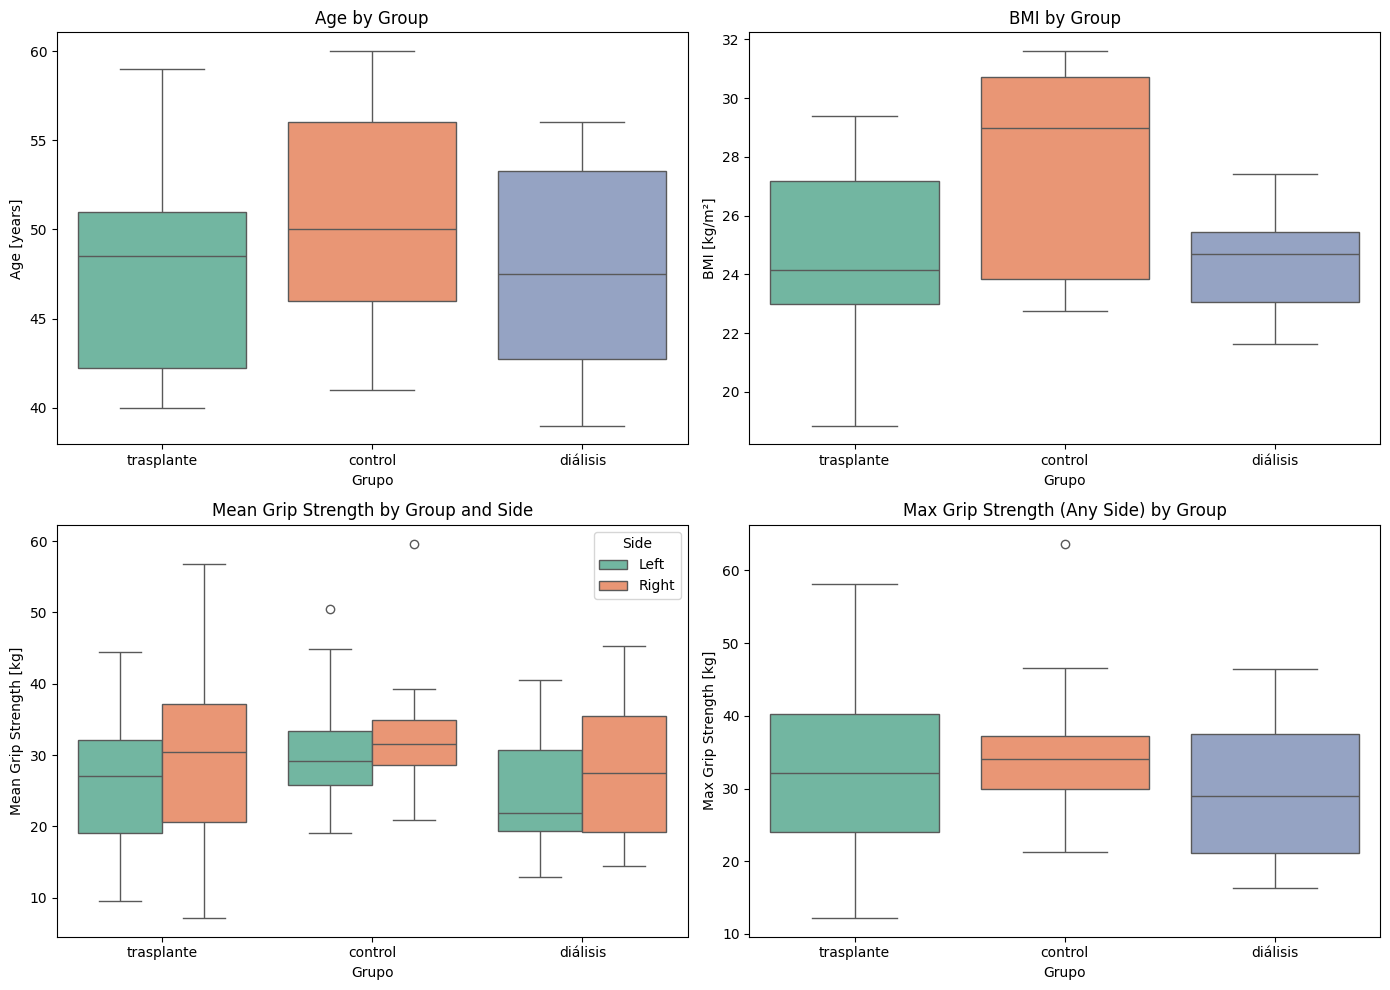

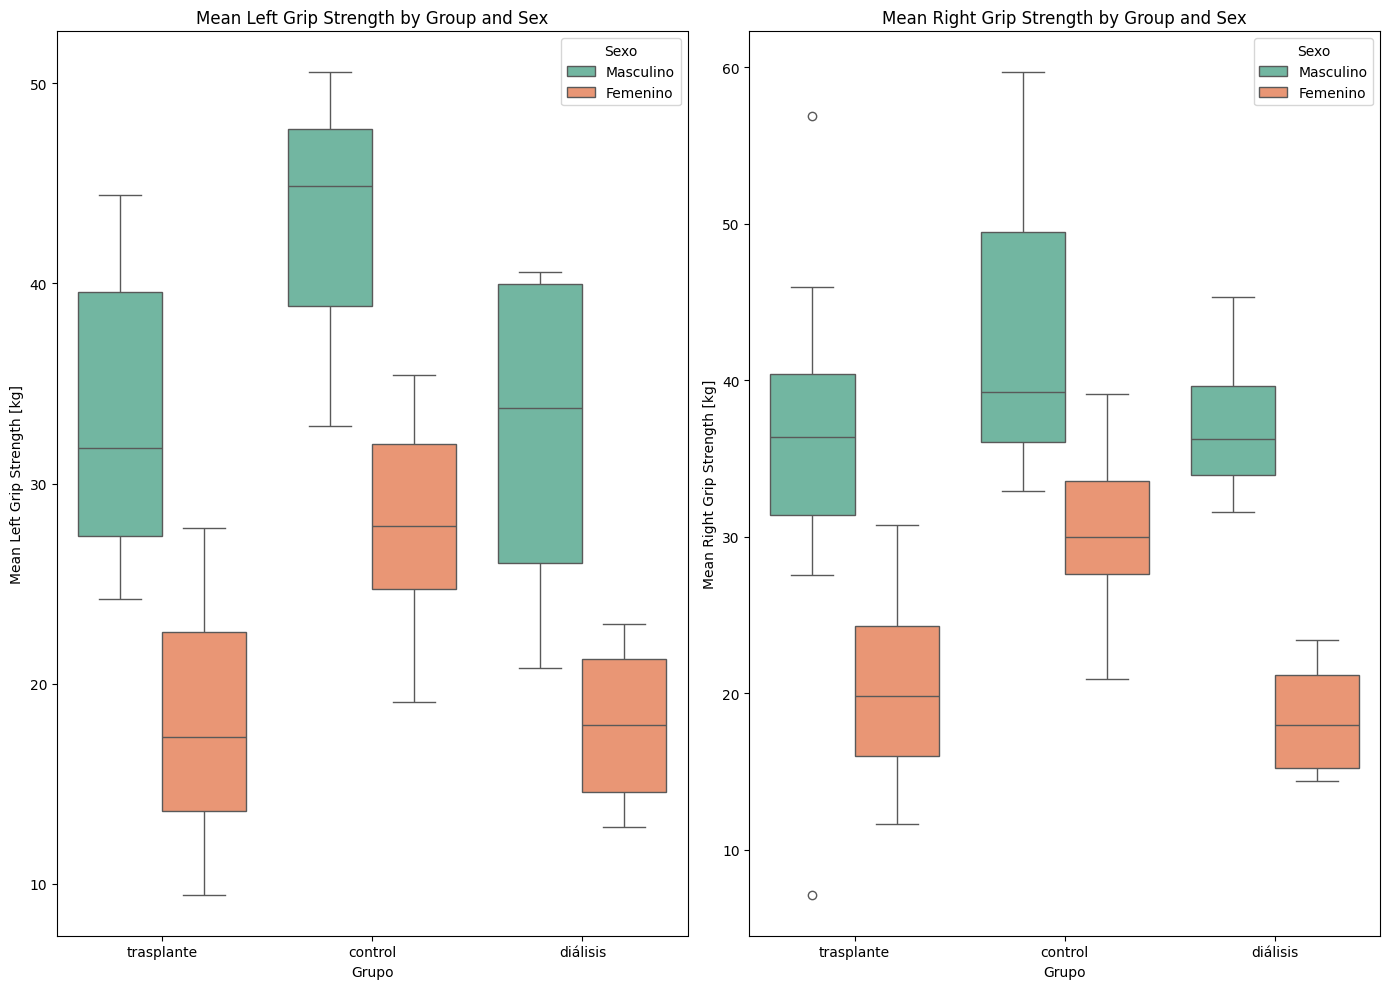

In [34]:
# Filter out rows with empty grip strength values
grip_columns = ['Izquierda-1', 'Izquierda-2', 'Izquierda-3', 'Derecha-1', 'Derecha-2', 'Derecha-3']
data = data.dropna(subset=grip_columns, how='all')

# Get descriptive statistics per group
print("=== Descriptive Statistics by Group ===\n")

# Age statistics
print("Age by Group:")
age_stats = data.groupby('Grupo')['Edad'].describe()
print(age_stats)
print("\n")

# Sex distribution by Group
print("Sex Distribution by Group:")
sex_stats = data.groupby(['Grupo', 'Sexo']).size().unstack(fill_value=0)
print(sex_stats)
print("\n")

# BMI statistics
print("BMI by Group:")
bmi_stats = data.groupby('Grupo')['BMI'].describe()
print(bmi_stats)
print("\n")

# Calculate mean and max grip strength per side
data['Mean_Izquierda'] = data[['Izquierda-1', 'Izquierda-2', 'Izquierda-3']].mean(axis=1)
data['Mean_Derecha'] = data[['Derecha-1', 'Derecha-2', 'Derecha-3']].mean(axis=1)
data['Max_Any_Side'] = data[['Izquierda-1', 'Izquierda-2', 'Izquierda-3', 'Derecha-1', 'Derecha-2', 'Derecha-3']].max(axis=1)

# Grip strength statistics
print("Mean Left Grip Strength by Group:")
mean_left_stats = data.groupby('Grupo')['Mean_Izquierda'].describe()
print(mean_left_stats)
print("\n")

print("Mean Right Grip Strength by Group:")
mean_right_stats = data.groupby('Grupo')['Mean_Derecha'].describe()
print(mean_right_stats)
print("\n")

print("Max Grip Strength (Any Side) by Group:")
max_grip_stats = data.groupby('Grupo')['Max_Any_Side'].describe()
print(max_grip_stats)
print("\n")

# Create boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot for Age
sns.boxplot(x='Grupo', y='Edad', data=data, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Age by Group')
axes[0, 0].set_ylabel('Age [years]')

# Boxplot for BMI
sns.boxplot(x='Grupo', y='BMI', data=data, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('BMI by Group')
axes[0, 1].set_ylabel('BMI [kg/m²]')

# Boxplot for Mean Grip Strength (Left and Right)
mean_grip_data = pd.melt(data, id_vars=['Grupo'], value_vars=['Mean_Izquierda', 'Mean_Derecha'], 
                         var_name='Side', value_name='Mean_Grip')
mean_grip_data['Side'] = mean_grip_data['Side'].replace({'Mean_Izquierda': 'Left', 'Mean_Derecha': 'Right'})
sns.boxplot(x='Grupo', y='Mean_Grip', hue='Side', data=mean_grip_data, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Mean Grip Strength by Group and Side')
axes[1, 0].set_ylabel('Mean Grip Strength [kg]')

# Boxplot for Max Grip Strength (Any Side)
sns.boxplot(x='Grupo', y='Max_Any_Side', data=data, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Max Grip Strength (Any Side) by Group')
axes[1, 1].set_ylabel('Max Grip Strength [kg]')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "boxplots_demographics_grip_by_group.png"))
plt.show()


# Create boxplots divided by sex per group
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Boxplot for Mean Left Grip Strength by Group and Sex
sns.boxplot(x='Grupo', y='Mean_Izquierda', hue='Sexo', data=data, ax=axes[0], palette='Set2')
axes[0].set_title('Mean Left Grip Strength by Group and Sex')
axes[0].set_ylabel('Mean Left Grip Strength [kg]')

# Boxplot for Mean Right Grip Strength by Group and Sex
sns.boxplot(x='Grupo', y='Mean_Derecha', hue='Sexo', data=data, ax=axes[1], palette='Set2')
axes[1].set_title('Mean Right Grip Strength by Group and Sex')
axes[1].set_ylabel('Mean Right Grip Strength [kg]')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "boxplots_demographics_grip_by_group_and_sex.png"))
plt.show()


=== Blood Test Statistics by Group ===

Hemoglobina by Group:
            count       mean       std   min     25%    50%    75%   max
Grupo                                                                   
control       9.0  14.022222  0.868588  12.4  13.500  14.20  14.50  15.2
diálisis      1.0  10.500000       NaN  10.5  10.500  10.50  10.50  10.5
trasplante   16.0  12.862500  2.046745   7.5  12.025  13.55  14.25  15.3


Creatininemia by Group:
            count      mean       std  min  25%   50%    75%  max
Grupo                                                            
control       9.0  0.833333  0.141421  0.6  0.8  0.80  0.900  1.1
diálisis      1.0  8.800000       NaN  8.8  8.8  8.80  8.800  8.8
trasplante   16.0  1.206250  0.437369  0.8  0.9  1.05  1.325  2.4


ColTotal by Group:
            count        mean        std    min    25%    50%    75%    max
Grupo                                                                      
control       9.0  196.777778  27.192728  16

/tmp/ipykernel_2285860/484164256.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y=blood_test, data=plot_data, ax=axes[idx], palette='Set2')
/tmp/ipykernel_2285860/484164256.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y=blood_test, data=plot_data, ax=axes[idx], palette='Set2')
/tmp/ipykernel_2285860/484164256.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y=blood_test, data=plot_data, ax=axes[idx], palette='Set2')
/tmp/ipykernel_2285860/484164256.py:21: FutureWarning: 

Passing `palette` w

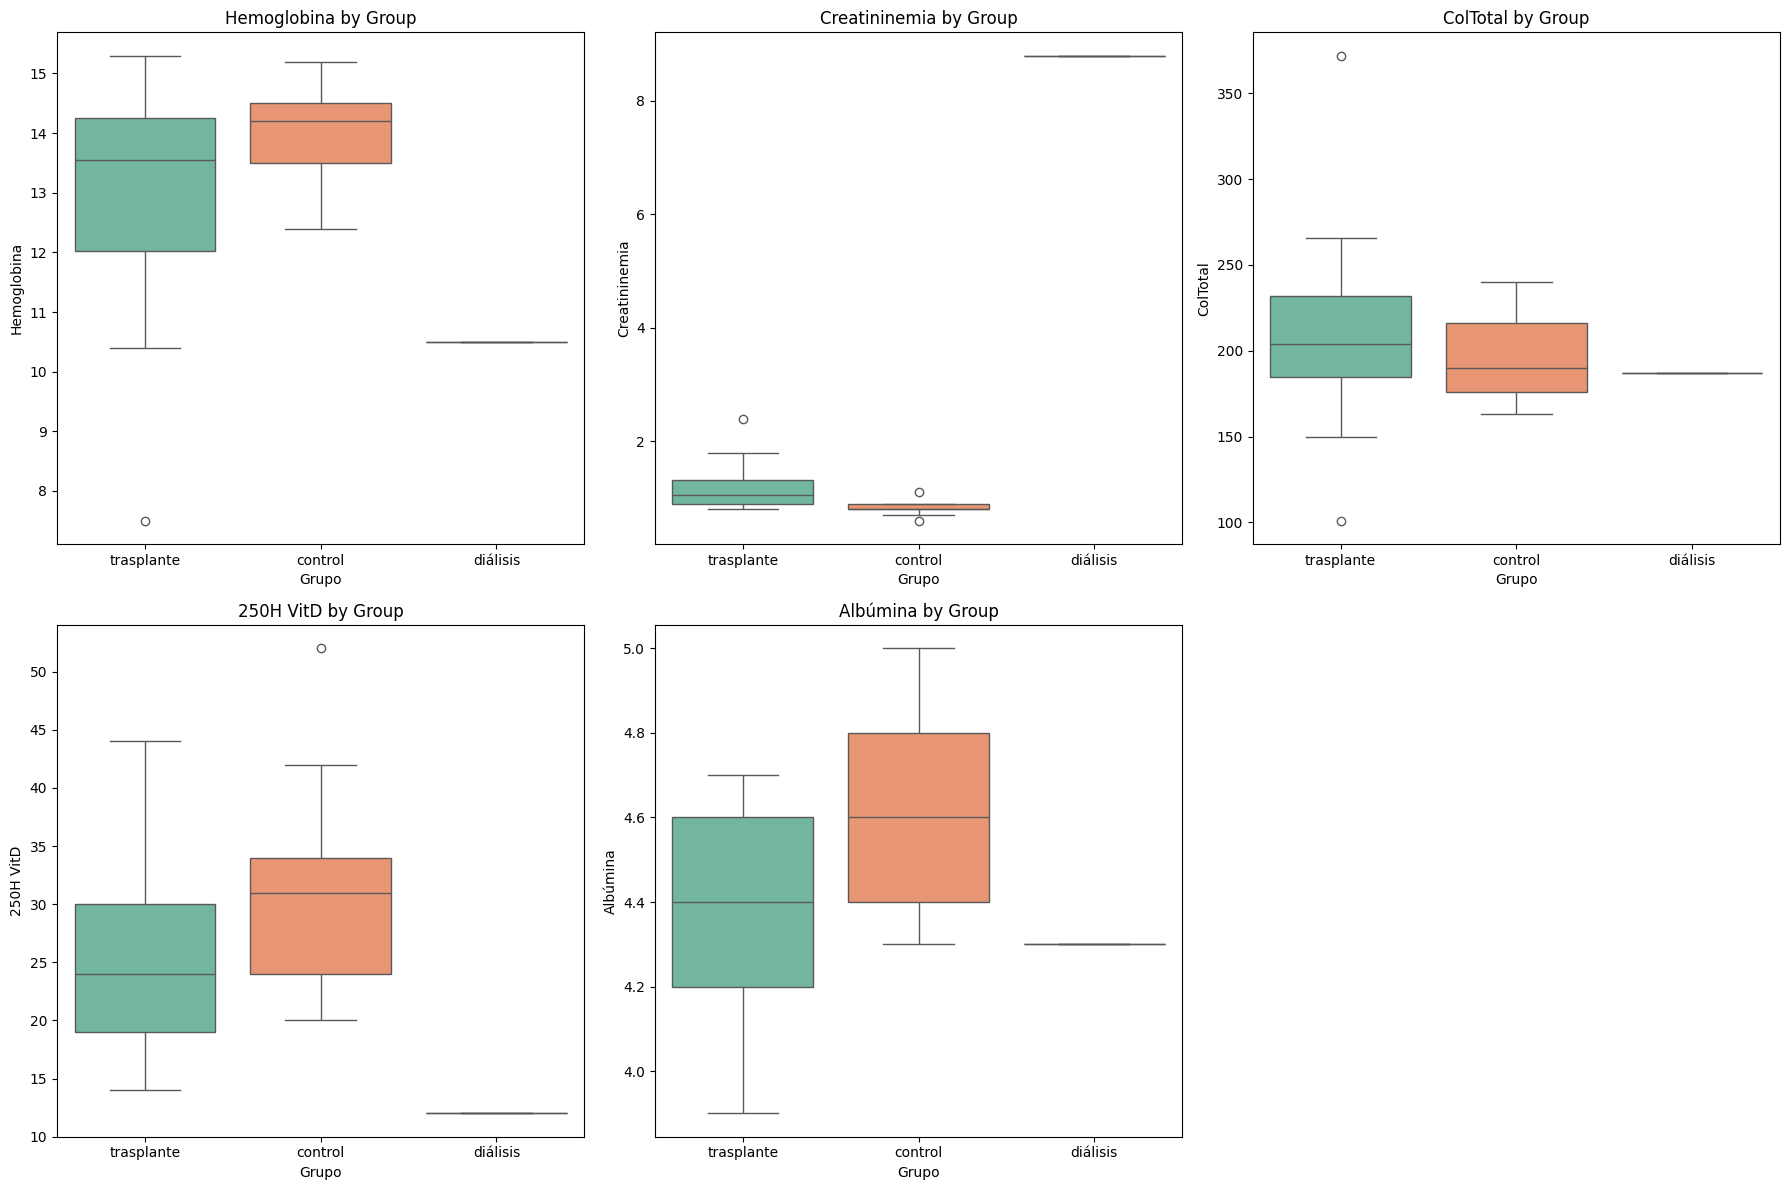

In [35]:
# Filter data with non-empty blood test values
blood_columns = ['Hemoglobina', 'Creatininemia', 'ColTotal', '250H VitD', 'Albúmina']

# Get descriptive statistics per group for blood tests
print("=== Blood Test Statistics by Group ===\n")

for blood_test in blood_columns:
    print(f"{blood_test} by Group:")
    blood_stats = data.groupby('Grupo')[blood_test].describe()
    print(blood_stats)
    print("\n")

# Create boxplots for blood tests
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, blood_test in enumerate(blood_columns):
    # Filter out NaN values for plotting
    plot_data = data[['Grupo', blood_test]].dropna()
    
    sns.boxplot(x='Grupo', y=blood_test, data=plot_data, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{blood_test} by Group')
    axes[idx].set_ylabel(blood_test)
    axes[idx].set_xlabel('Grupo')

# Remove the extra subplot
axes[-1].remove()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "boxplots_blood_tests_by_group.png"))
plt.show()

In [36]:
print(filtered_data['Group'])
# Plot box plots for fat fraction:

for muscle in ['GMAX', 'GMED', 'GMIN', 'TFL']:
    sns.boxplot(x='Group', y=f'FF_{muscle}', data=filtered_data, showfliers=False, palette='Set2')
    sns.stripplot(x='Group', y=f'FF_{muscle}', data=filtered_data, hue='Sex', 
                  palette={'Male': 'blue', 'Female': 'red'}, alpha=0.6, jitter=True, size=8, 
                  marker='o' if filtered_data['Sex'].iloc[0] == 'Male' else 'X')
    plt.ylabel('Fat Fraction [%]')
    plt.title(f'{muscle} Fat Infiltration by Group')
    plt.ylim(0, 25)
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f"boxplot_ff_{muscle}_by_group.png"))
    plt.show()
    plt.close()

NameError: name 'filtered_data' is not defined

C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\2387573727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=f'NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')


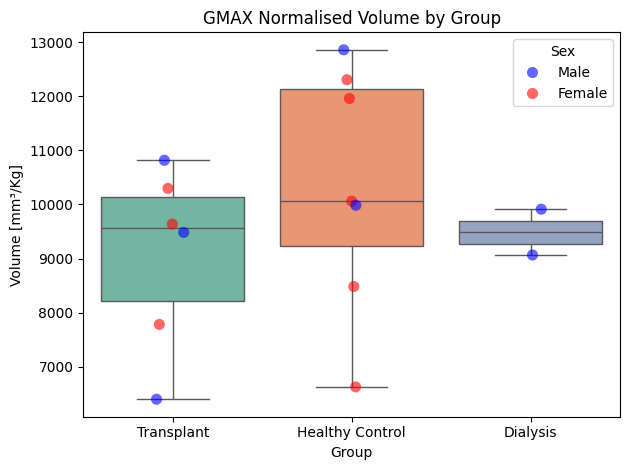

C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\2387573727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=f'NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')


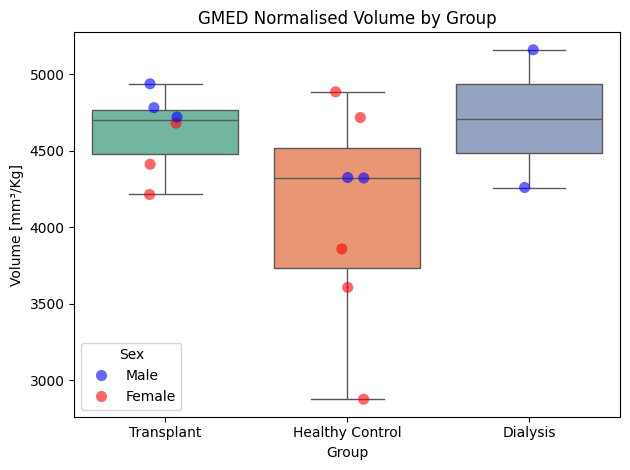

C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\2387573727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=f'NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')


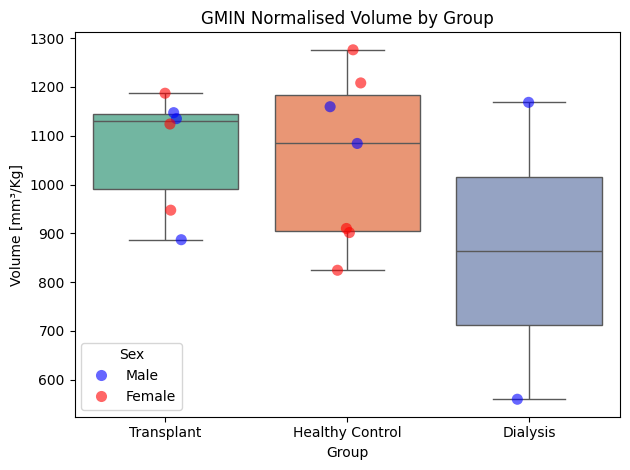

C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\2387573727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=f'NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')


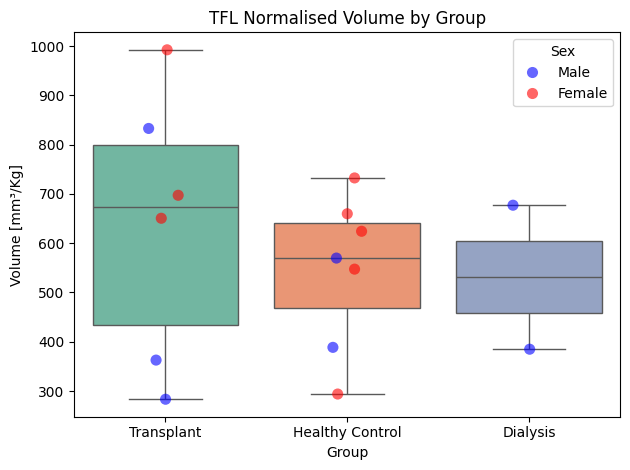

In [ ]:
# Plot box plots for volume:

for muscle in ['GMAX', 'GMED', 'GMIN', 'TFL']:
    sns.boxplot(x='Group', y=f'NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')
    sns.stripplot(x='Group', y=f'NORM_VOL_{muscle}', data=filtered_data, hue='Sex', 
                  palette={'Male': 'blue', 'Female': 'red'}, alpha=0.6, jitter=True, size=8, 
                  marker='o' if filtered_data['Sex'].iloc[0] == 'Male' else 'X')
    plt.ylabel('Volume [mm³/Kg]')
    plt.title(f'{muscle} Normalised Volume by Group')
    #plt.ylim(0, 25)
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f"boxplot_norm_vol_{muscle}_by_group.png"))
    plt.show()
    plt.close()


C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\2291546559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=f'LEAN_NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')


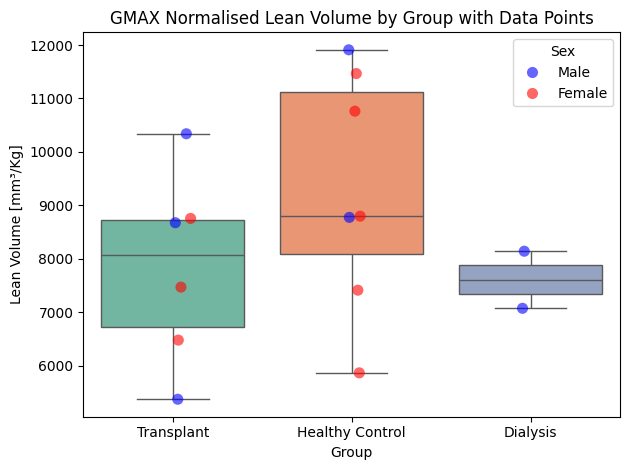

C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\2291546559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=f'LEAN_NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')


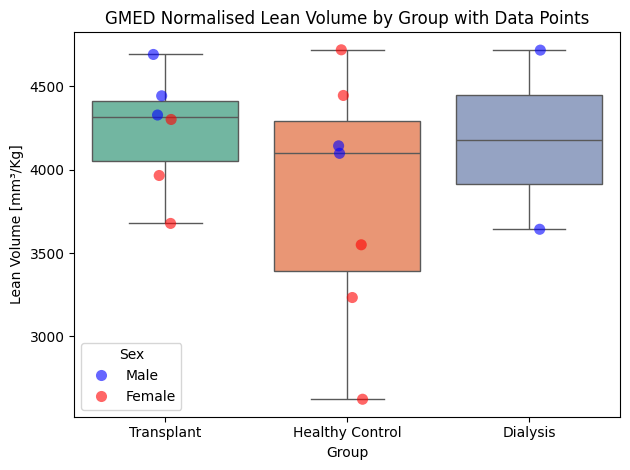

C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\2291546559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=f'LEAN_NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')


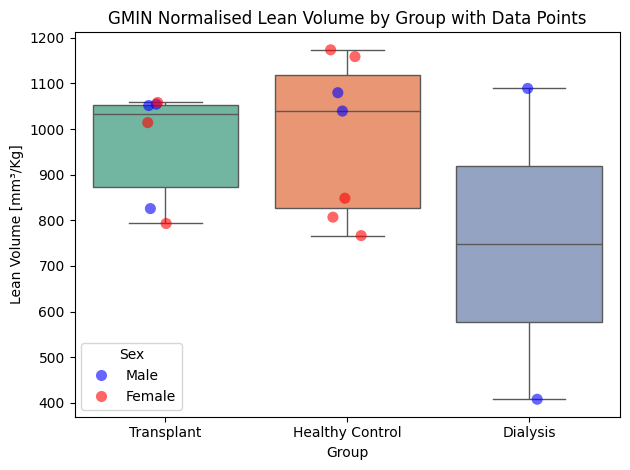

C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\2291546559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=f'LEAN_NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')


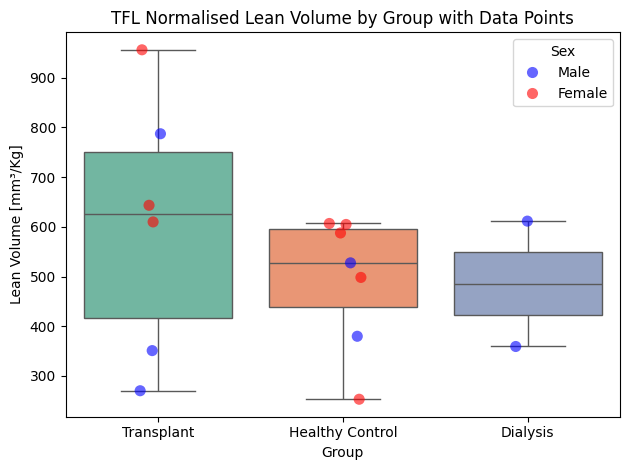

In [ ]:
for muscle in ['GMAX', 'GMED', 'GMIN', 'TFL']:
    sns.boxplot(x='Group', y=f'LEAN_NORM_VOL_{muscle}', data=filtered_data, showfliers=False, palette='Set2')
    sns.stripplot(x='Group', y=f'LEAN_NORM_VOL_{muscle}', data=filtered_data, hue='Sex', 
                  palette={'Male': 'blue', 'Female': 'red'}, alpha=0.6, jitter=True, size=8, 
                  marker='o' if filtered_data['Sex'].iloc[0] == 'Male' else 'X')
    plt.ylabel('Lean Volume [mm³/Kg]')
    plt.title(f'{muscle} Normalised Lean Volume by Group with Data Points')
    #plt.ylim(0, 25)
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f"boxplot_lean_vol_{muscle}_by_group.png"))
    plt.show()
    plt.close()


C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\1001115094.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=variable, data=filtered_data, showfliers=False, palette='Set2')


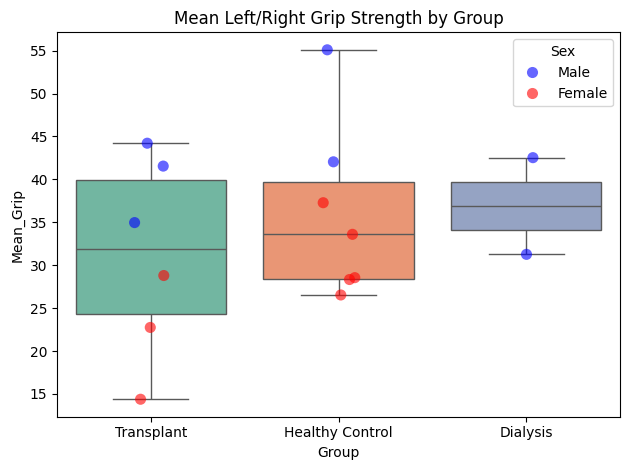

In [ ]:
filtered_data['Mean_Izquierda'] = filtered_data[['Izquierda-1', 'Izquierda-2', 'Izquierda-3']].mean(axis=1)
filtered_data['Mean_Derecha'] = filtered_data[['Derecha-1', 'Derecha-2', 'Derecha-3']].mean(axis=1)
filtered_data['Max_Izquierda'] = filtered_data[['Izquierda-1', 'Izquierda-2', 'Izquierda-3']].max(axis=1)
filtered_data['Max_Derecha'] = filtered_data[['Derecha-1', 'Derecha-2', 'Derecha-3']].max(axis=1)
filtered_data['Mean_Grip'] = (filtered_data['Mean_Izquierda'] + filtered_data['Mean_Derecha']) / 2
filtered_data['Max_Grip'] = (filtered_data['Max_Izquierda'] + filtered_data['Max_Derecha']) / 2
variables_to_plot = ['Mean_Grip']#, 'Max_Grip']
# Create boxplots for Mean_Grip and Max_Grip by groups with points
for variable in variables_to_plot:
    sns.boxplot(x='Group', y=variable, data=filtered_data, showfliers=False, palette='Set2')
    sns.stripplot(x='Group', y=variable, data=filtered_data, hue='Sex', 
                  palette={'Male': 'blue', 'Female': 'red'}, alpha=0.6, jitter=True, size=8, 
                  marker='o' if filtered_data['Sex'].iloc[0] == 'Male' else 'X')
    plt.ylabel(f'{variable}')
    plt.title(f'Mean Left/Right Grip Strength by Group')
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f"boxplot_{variable}_by_group.png"))
    plt.show()
    plt.close()



Muscle: GMAX, R²: 0.18, Slope: -0.2237, R: -0.4220


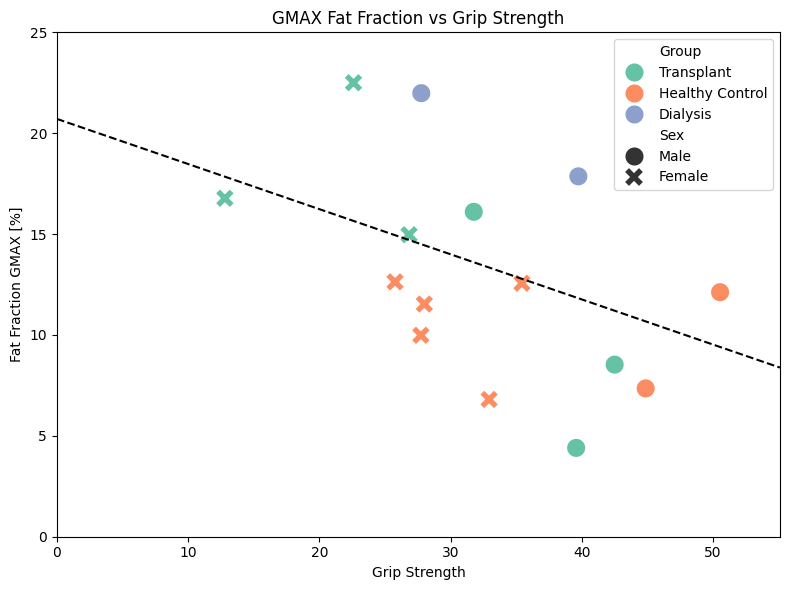

Muscle: GMED, R²: 0.30, Slope: -0.1675, R: -0.5454


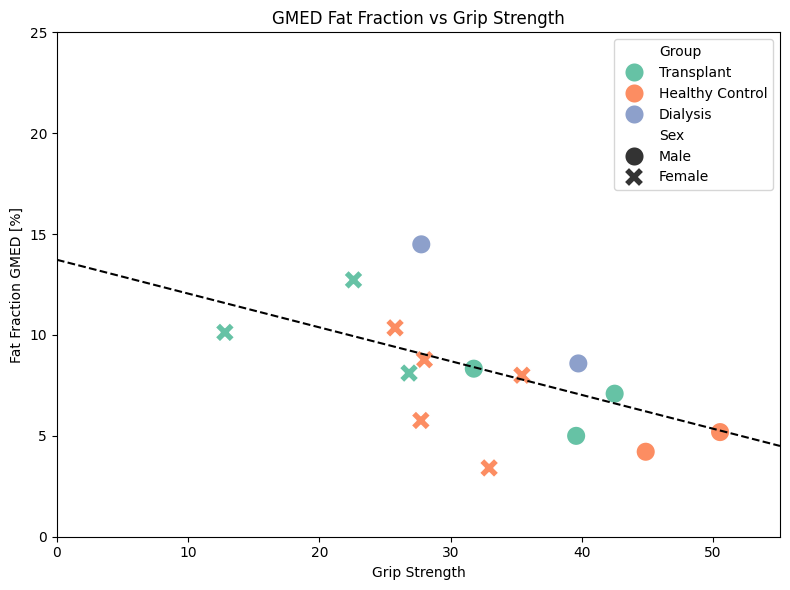

Muscle: GMIN, R²: 0.10, Slope: -0.1776, R: -0.3092


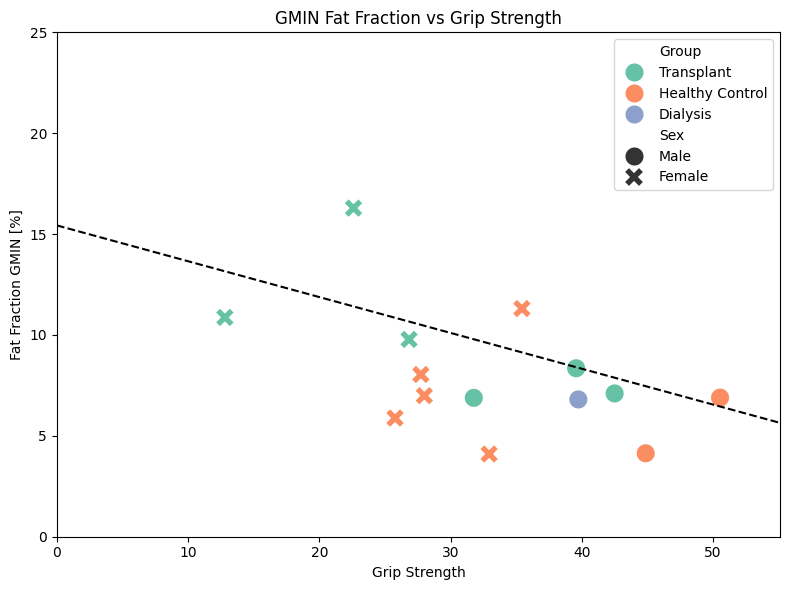

Muscle: TFL, R²: 0.00, Slope: -0.0038, R: -0.0097


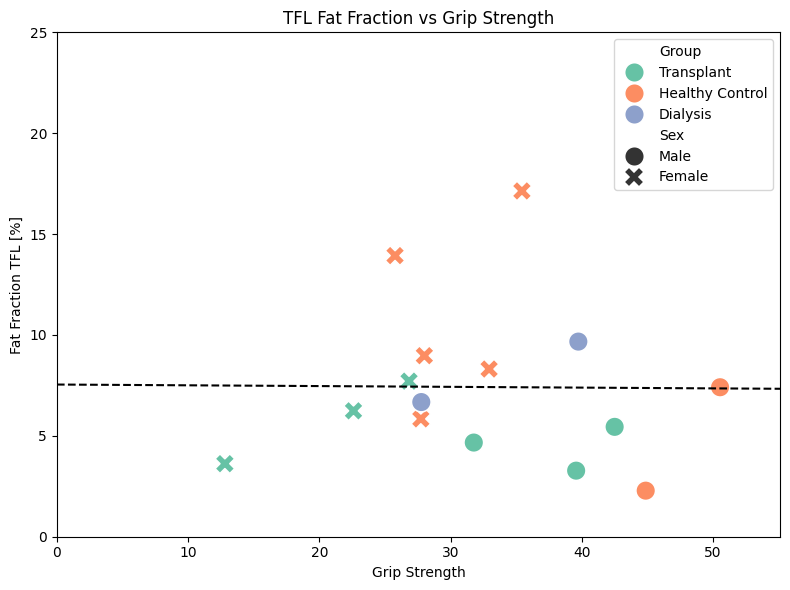

In [ ]:
for muscle in ['GMAX', 'GMED', 'GMIN', 'TFL']:
    # Fit a linear regression model
    slope, intercept, r_value, p_value, std_err = stats.linregress(filtered_data['Mean_Grip'], filtered_data[f'FF_{muscle}'])
    # Add the regression line to the plot
    x_vals = np.linspace(0, filtered_data['Mean_Grip'].max(), 100)
    y_vals = slope * x_vals + intercept
    print(f"Muscle: {muscle}, R²: {r_value**2:.2f}, Slope: {slope:.4f}, R: {r_value:.4f}")
   # print(x_vals)
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='Mean_Izquierda', y=f'FF_{muscle}', data=filtered_data, hue='Group', style='Sex', palette='Set2', s=200)
    plt.plot(x_vals, y_vals, color='black', linestyle='--', label=f'Linear Fit (R²={r_value**2:.2f})')
    plt.xlabel('Grip Strength')
    plt.ylabel(f'Fat Fraction {muscle} [%]')
    plt.xlim(0, filtered_data['Mean_Grip'].max())
    plt.ylim(0, 25)
    #plt.legend()
    plt.title(f'{muscle} Fat Fraction vs Grip Strength')
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f"scatter_ff_{muscle}_vs_grip_strength.png"))
    plt.show()

C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\3317127186.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='FF_GMAX', data=filtered_data, palette='muted', inner=None)
C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\3317127186.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='FF_GMAX', data=filtered_data, palette='muted', inner=None)
C:\Users\Martin\AppData\Local\Temp\ipykernel_26536\3317127186.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='FF_GMAX', data=filtered_data, pal

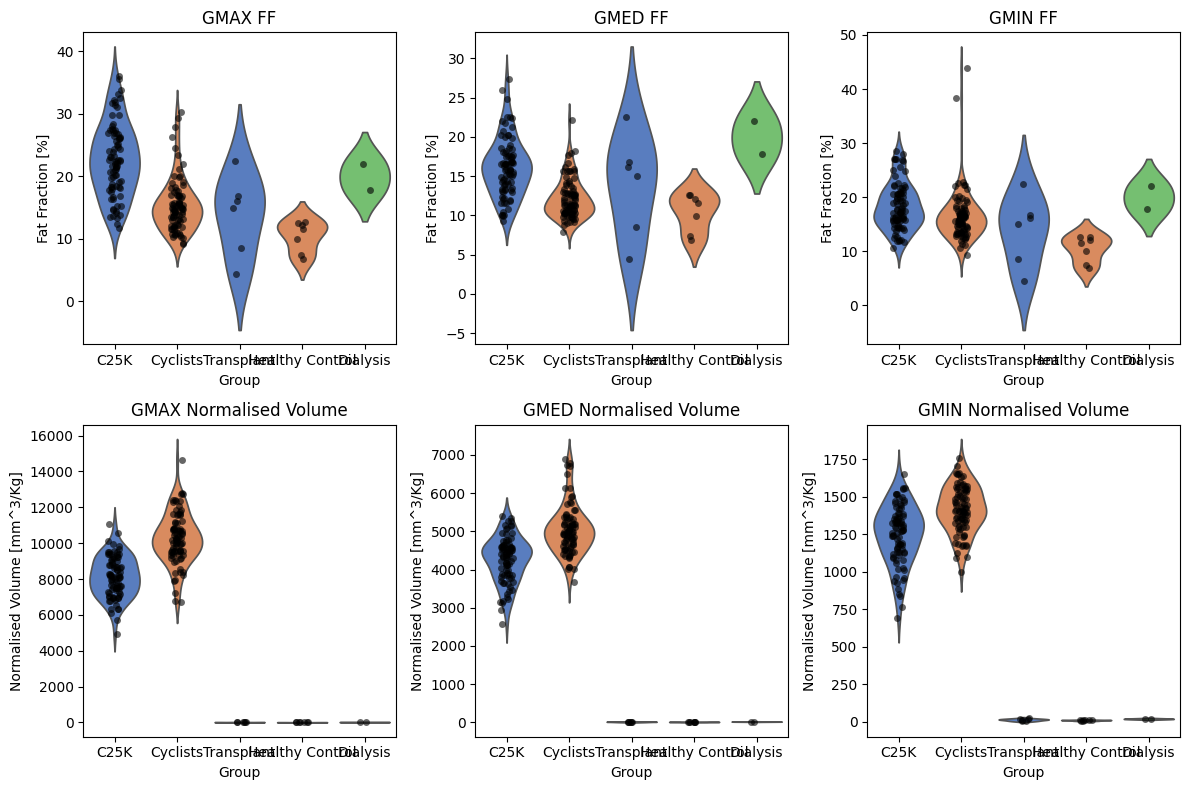

In [ ]:
# Now compare to groups from a different study (warning: different protocol)
results_cto5k_filename = "D:/Work/Publications/2025_CoreScore/DataAnalysis/CoreScore/merged_data.csv"
cto5k_pd = pd.read_csv(results_cto5k_filename)
# Variable names:
names_ff_to_merge = [
    'ffMeanSides_1', 'ffMeanSides_2', 'ffMeanSides_3', 'ffMeanSides_4', 'GMAX', 'GMED', 'GMIN']
names_vol_to_merge = [
    'meanVolume_mm3_1', 'meanVolume_mm3_2', 'meanVolume_mm3_3', 'meanVolume_mm3_4', 'GMAX_vol', 'GMED_vol', 'GMIN_vol']
names_nvol_to_merge = [
    'normMeanVolume_mm3_1', 'normMeanVolume_mm3_2', 'normMeanVolume_mm3_3', 'normMeanVolume_mm3_4', 'GMAX_nvol', 'GMED_nvol', 'GMIN_nvol']
names_lvol_to_merge = [
    'meanLeanVolume_mm3_1', 'meanLeanVolume_mm3_2', 'meanLeanVolume_mm3_3', 'meanLeanVolume_mm3_4', 'GMAX_lvol', 'GMED_lvol', 'GMIN_lvol']
names_nlvol_to_merge = [
    'normMeanLeanVolume_mm3_1', 'normMeanLeanVolume_mm3_2', 'normMeanLeanVolume_mm3_3', 'normMeanLeanVolume_mm3_4', 'GMAX_nlvol', 'GMED_nlvol', 'GMIN_nlvol']

# Set up the figure
plt.figure(figsize=(12, 8))
variables_to_plot = ['GMAX', 'GMED', 'GMIN', 'GMAX_nvol', 'GMED_nvol', 'GMIN_nvol']
variables_names_for_titles = {
    'GMAX': 'GMAX FF',
    'GMED':  'GMED FF',
    'GMIN':  'GMIN FF',
    'GMAX_nvol': 'GMAX Normalised Volume',
    'GMED_nvol': 'GMED Normalised Volume',
    'GMIN_nvol': 'GMIN Normalised Volume'
}
ylabel_names = {
    'GMAX': 'Fat Fraction [%]',
    'GMED':  'Fat Fraction [%]',
    'GMIN': 'Fat Fraction [%]',
    'GMAX_nvol': 'Normalised Volume [mm^3/Kg]',
    'GMED_nvol': 'Normalised Volume [mm^3/Kg]',
    'GMIN_nvol': 'Normalised Volume [mm^3/Kg]',
}

#Equise both measurements:
offset_protocols = -2
cto5k_pd_copy = cto5k_pd.copy()
cto5k_pd_copy['GMAX'] = cto5k_pd_copy['GMAX'] + offset_protocols
cto5k_pd_copy['GMED'] = cto5k_pd_copy['GMED'] + offset_protocols
cto5k_pd_copy['GMIN'] = cto5k_pd_copy['GMIN'] + offset_protocols

# Plot violin plots with individual dots for each variable
for i, variable in enumerate(variables_to_plot, 1):
    plt.subplot(2, 3, i)  # Create a subplot grid
    sns.violinplot(x='group', y=variable, data=cto5k_pd, palette='muted', inner=None, hue='group', split=False)
    sns.stripplot(x='group', y=variable, data=cto5k_pd, color='black', alpha=0.6, jitter=True)
    sns.violinplot(x='Group', y='FF_GMAX', data=filtered_data, palette='muted', inner=None)
    sns.stripplot(x='Group', y='FF_GMAX', data=filtered_data, color='black', alpha=0.6, jitter=True)
    plt.title(f'{variables_names_for_titles[variable]}')
    plt.xlabel('Group')
    plt.ylabel(f'{ylabel_names[variable]}')

# Adjust layout and show the plots
plt.tight_layout()
plt.savefig(output_path + "violin_plots_core_score_group.png")
plt.show()